# Introduction

This notebook walks throught the production of Fig. 04, a two-panel figure where panel a) is the spectrum of low- and high-variability winds and the spectrum of the Stokes drift and significant wave height from WW3-LVWD and WW3-HVWD, and panel b) is the coherence between the magnitude of the LVWD and HVWD and the magnitude of the Stokes drift from the four main simulations against the appropriate wind field. Confidence intervals for the spectra and a confidence level for the coherence are estimated form a chi-2 distribution considering a 1-week decorrelation scale (see `../analysis/decorrelation_scale.ipynb`). The panels are plotted separately and then combined in the manuscript $\LaTeX$ file.

## Imports

In [79]:
import sys
sys.path.append("../src")

In [80]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from spec_plot import (
    plot_spectra,
    add_spectral_slope,
    plot_coherence,
)

from spectral_analysis import (
    isotropize,
    CI,
)

plt.rcdefaults()
plt.style.use("../src/paper.mplstyle")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data

In [81]:
INPUT_DIR = Path('../data/')

For panel a), we will plot the spectra of the low-variability winds (LVWD), highv-variability winds (HVWD), and wave varianbles from the WW3-LVWD and WW3-HVWD models.

In [82]:
ww3_lvwd = xr.open_zarr(INPUT_DIR / 'spectra/lvwd.zarr', consolidated=False)
ww3_hvwd = xr.open_zarr(INPUT_DIR / 'spectra/hvwd.zarr', consolidated=False)

For panel b), we will plot the coherenece between the wind forcing magnitude and the Stokes drift, computed in `analysis/compute_coherence_winds.py`.

In [83]:
coh_lvwd_us = xr.open_zarr(INPUT_DIR / 'coherence/lvwd_us.zarr', consolidated=False)
coh_hvwd_us = xr.open_zarr(INPUT_DIR / 'coherence/hvwd_us.zarr', consolidated=False)
coh_lvwd_cur_us = xr.open_zarr(INPUT_DIR / 'coherence/lvwd_cur_us.zarr', consolidated=False)
coh_hvwd_cur_us = xr.open_zarr(INPUT_DIR / 'coherence/hvwd_cur_us.zarr', consolidated=False)

# Mean 1D Spectra and Error Estimation

We first take the data above (which is 2D spectra at each timestep for each component of the vector) and compute the vector variance spectrum, take the mean across time, and isotropize (take the azimuthal average).

In [84]:
lvwd_vecspec = (ww3_lvwd.uwnd_PSD + ww3_lvwd.vwnd_PSD)
hvwd_vecspec = (ww3_hvwd.uwnd_PSD + ww3_hvwd.vwnd_PSD)

us_lvwd_vecspec = (ww3_lvwd.uuss_PSD + ww3_lvwd.vuss_PSD)
us_hvwd_vecspec = (ww3_hvwd.uuss_PSD + ww3_hvwd.vuss_PSD)

hs_lvwd_spec = ww3_lvwd.hs_PSD
hs_hvwd_spec = ww3_hvwd.hs_PSD

In [85]:
ww3_lvwd.close(); del ww3_lvwd
ww3_hvwd.close(); del ww3_hvwd

In [86]:
mean_lvwd_vecspec = lvwd_vecspec.mean(dim='time')
mean_hvwd_vecspec = hvwd_vecspec.mean(dim='time')

mean_us_lvwd_vecspec = us_lvwd_vecspec.mean(dim='time')
mean_us_hvwd_vecspec = us_hvwd_vecspec.mean(dim='time')

mean_hs_lvwd_spec = hs_lvwd_spec.mean(dim='time')
mean_hs_hvwd_spec = hs_hvwd_spec.mean(dim='time')

In [87]:
mean_iso_lvwd_vecspec = isotropize(mean_lvwd_vecspec)
mean_iso_hvwd_vecspec = isotropize(mean_hvwd_vecspec)

mean_iso_us_lvwd_vecspec = isotropize(mean_us_lvwd_vecspec)
mean_iso_us_hvwd_vecspec = isotropize(mean_us_hvwd_vecspec)

mean_iso_hs_lvwd_spec = isotropize(mean_hs_lvwd_spec)
mean_iso_hs_hvwd_spec = isotropize(mean_hs_hvwd_spec)

We estimate error from the chi-2 distribution. The data is hourly, however the number of degrees of freedom for the chi-2 distribution needs to take into consideration the timescale at which a given variable becomes decorrelated with itself. See `../analysis/decorrelation_scale.ipynb` for the analysis done to compute the decorrelation scale for each variable. For all wind, current, and wave variables, the decorrelation scale is O(days). So here, we used a decorrelation scale of 1 week for all variables as a conservative estimate of error.

In [88]:
M_1wk = hvwd_vecspec.time.count() / 24 / 7

By default, the function computes 95% confidence intervals.

In [89]:
mean_iso_lvwd_vecspec = CI(mean_iso_lvwd_vecspec, M_1wk)
mean_iso_hvwd_vecspec = CI(mean_iso_hvwd_vecspec, M_1wk)

mean_iso_us_lvwd_vecspec = CI(mean_iso_us_lvwd_vecspec, M_1wk)
mean_iso_us_hvwd_vecspec = CI(mean_iso_us_hvwd_vecspec, M_1wk)

mean_iso_hs_lvwd_spec = CI(mean_iso_hs_lvwd_spec, M_1wk)
mean_iso_hs_hvwd_spec = CI(mean_iso_hs_hvwd_spec, M_1wk)

## Plotting Panel a)

In [90]:
panel_a = {
    "hvwd": {
        "data": mean_iso_lvwd_vecspec,
        "color": "goldenrod",
        "linestyle": "-",
        "label": "$\mathbf{U}_\mathrm{HVWD}$",
        "linewidth": 1.5,
        "plot_CI": True,
        "CI_alpha": 0.2,
    },
    "lvwd": {
        "data": mean_iso_hvwd_vecspec,
        "color": "goldenrod",
        "linestyle": "--",
        "label": "$\mathbf{U}_\mathrm{LVWD}$",
        "linewidth": 1.5,
        "plot_CI": True,
        "CI_alpha": 0.2,
    },
# ---
    "us-hvwd": {
        "data": mean_iso_us_lvwd_vecspec * 1e2,
        "color": "mediumseagreen",
        "linestyle": "-",
        "label": "$\mathbf{U}_\mathrm{s, HVWD}$",
        "linewidth": 1.5,
        "plot_CI": True,
        "CI_alpha": 0.2,
    },
    "us-lvwd": {
        "data": mean_iso_us_hvwd_vecspec * 1e2,
        "color": "mediumseagreen",
        "linestyle": "--",
        "label": "$\mathbf{U}_\mathrm{s, LVWD}$",
        "linewidth": 1.5,
        "plot_CI": True,
        "CI_alpha": 0.2,
    },

# ---
    "hs-hvwd": {
        "data": mean_iso_hs_lvwd_spec * 1e-2,
        "color": "lightcoral",
        "linestyle": "-",
        "label": "$H_\mathrm{s, HVWD}$",
        "linewidth": 1.5,
        "plot_CI": True,
        "CI_alpha": 0.2,
    },
    "hs-lvwd": {
        "data": mean_iso_hs_hvwd_spec * 1e-2,
        "color": "lightcoral",
        "linestyle": "--",
        "label": "$H_\mathrm{s, LVWD}$",
        "linewidth": 1.5,
        "plot_CI": True,
        "CI_alpha": 0.2,
    },
}

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1437598/2667452653.py:6: SyntaxWarning: invalid escape sequence '\m'
  "label": "$\mathbf{U}_\mathrm{HVWD}$",
/tmp/ipykernel_1437598/2667452653.py:15: SyntaxWarning: invalid escape sequence '\m'
  "label": "$\mathbf{U}_\mathrm{LVWD}$",
/tmp/ipykernel_1437598/2667452653.py:25: SyntaxWarning: invalid escape sequence '\m'
  "label": "$\mathbf{U}_\mathrm{s, HVWD}$",
/tmp/ipyke

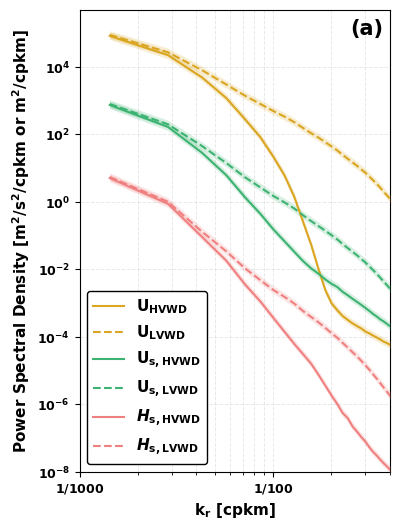

In [91]:
fig, ax = plot_spectra(
    panel_a,
    ylab='Power Spectral Density [m$^2$/s$^2$/cpkm or m$^2$/cpkm]',
    figsize=(4,6),
    # slopes=[-3, -3.5, -4],
    xlim=(1e-3, 1/25),
    ylim=[1e-8, 5e5]
)

ax.text(
    0.98, 0.98,
    "(a)",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=15,
    fontweight="bold",
)

plt.show()

# Coherence, Panel b)

The coherence data are already ready for plotting.

In [92]:
panel_b = {
    r"$U_\mathrm{LVWD} \rightarrow U_\mathrm{s, LVWD}$": {
        "ds": coh_lvwd_us,
        "color": "mediumseagreen",
        "linestyle": "--",
        "linewidth": 1.5,
    },
    r"$U_\mathrm{HVWD} \rightarrow U_\mathrm{s, HVWD}$": {
        "ds": coh_hvwd_us,
        "color": "mediumseagreen",
        "linestyle": "-",
        "linewidth": 1.5,
    },
    r"$U_\mathrm{LVWD} \rightarrow U_\mathrm{s, LVWD&CUR}$": {
        "ds": coh_lvwd_cur_us,
        "color": "darkgreen",
        "linestyle": "--",
        "linewidth": 1.5,
    },
    r"$U_\mathrm{HVWD} \rightarrow U_\mathrm{s, HVWD&CUR}$": {
        "ds": coh_hvwd_cur_us,
        "color": "darkgreen",
        "linestyle": "-",
        "linewidth": 1.5,
    },
}

We add in vertical lines at wavenumbers where peaks in the divergent component of the current are seen. See `notebooks/fig02.ipynb` for more details.

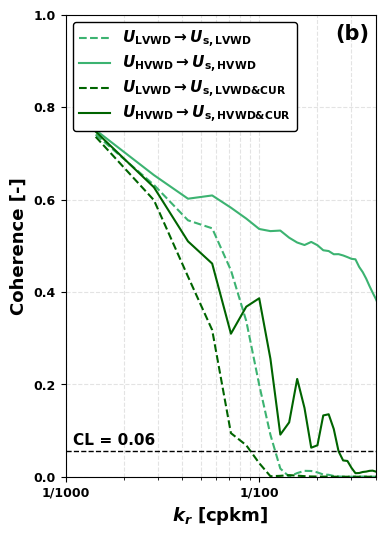

In [93]:
fig, ax = plot_coherence(
    panel_b,
    figsize=(4, 6),
    xlim=(1e-3, 1/25)
)

# ------------------------------------------------------------
# Add peak locations to both panels
# ------------------------------------------------------------
# for kr in div_peaks.kr.values:
#     ax.axvline(
#         kr,
#         color='black',
#         linestyle='--',
#         linewidth=0.8,
#         zorder=4,
#     )

#     # Label only on top panel
#     ax.text(
#         kr * 1.02,
#         0.76,
#         f"1/{1/kr:.0f} cpkm",
#         transform=ax.get_xaxis_transform(),
#         rotation=90,
#         ha='center',
#         va='top',
#         fontsize=10,
#         color='black',
#         bbox=dict(
#             facecolor='white',
#             edgecolor='none',
#             alpha=1.0,
#             pad=0.5
#         ),
#         zorder=5,
#     )

ax.text(
    0.98, 0.98,
    "(b)",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=15,
    fontweight="bold",
)

ax.legend(
        loc="upper left",
        frameon=True,
        framealpha=1.0,
        facecolor="white",
        edgecolor="black",
        labelspacing=0.25,
    )

plt.show()